In [1]:
import pandas as pd
import glob
import re
import os
from functions import *

Clean NTN 

In [2]:
# Load all sheets into a dictionary of DataFrames
xls = pd.read_excel('data_origin/omi_ntn/residential/RES_valori.xlsx', sheet_name=None)

# Add sheet name as a new column and concatenate
df = pd.concat(
    [sheet.assign(sheet_name=sheet_name) for sheet_name, sheet in xls.items()],
    ignore_index=True
)

# Extract year from sheet name
df['year'] = df['sheet_name'].str.extract(r"_(\d{4})(?:_|$)").astype(int)

# Drop unnecessary columns
df_ntn = df.drop(columns=['sheet_name', 'AREA', 'reg_name', 'prov'])

# Rename columns
df_ntn = df_ntn.rename(columns={'code': 'land_code', " upto_50": "upto_50"})

Import ISTAT codes

In [3]:
# Import ISTAT codes
df_istat = pd.read_csv('datasets/mun_istat_codes_non_normalized.csv')

In [4]:
# Merge with ISTAT codes
df_ntn_istat = pd.merge(df_ntn, df_istat[['land_code', 'mun_istat']], on = 'land_code', how = 'left')

# Drop land_code column
df_ntn_istat = df_ntn_istat.drop(columns = ['land_code'])

# Drop rows with missing values
df_ntn_istat = df_ntn_istat.dropna()

# Normalize ISTAT codes
df_ntn_istat['mun_istat'] = df_ntn_istat['mun_istat'].astype(int)
add_zeroes(df_ntn_istat, ['mun_istat'], 6)

,upto_50,50_85,85_115,115_145,over_145,NTN,year,mun_istat
0,2183,5067,3949,13.0,605.0,13104,2014,010001
1,0,35,3,25.0,1.0,10,2014,010002
2,2,633,625,375.0,3.0,2133,2014,010003
3,308,1017,95,10.0,3.0,3575,2014,010004
4,0,2,425,1.0,4.0,1125,2014,010005
...,...,...,...,...,...,...,...,...
83569,0,2,3,0.0,3.0,8,2015,046037
83570,0,4,125,417.0,897.0,2964,2015,097092
83571,0,0,0,0.0,0.0,0,2015,035046
83572,5,2125,2493,1267.0,1575.0,796,2015,037062


Save data

In [45]:
df_ntn_istat.to_csv('datasets/omi_ntn/omi_ntn_residential.csv', index=False)

In [9]:
df_ntn_istat[df_ntn_istat['mun_istat'] == '015146']

,upto_50,50_85,85_115,115_145,over_145,NTN,year,mun_istat
1209,266825,664367,354654,161532.0,139235.0,1586613,2014,015146
11463,526312,1034756,471714,202905.0,163003.0,239869,2024,015146
19026,524268,1082922,511472,198586.0,167543.0,2484791,2023,015146
26590,611105,126718,580846,225918.0,17666.0,2861709,2022,015146
34153,558495,11656,54731,225147.0,19838.0,2694932,2021,015146
41716,473593,918278,443026,177225.0,152857.0,2164979,2020,015146
49278,559368,1110524,530475,226637.0,196147.0,2623151,2019,015146
56877,500621,1037054,514801,216882.0,183237.0,2452595,2018,015146
64497,44219,12945,54175,21692.0,185742.0,237233,2017,015146
69475,390032,943821,479165,203067.0,176153.0,2192238,2016,015146


<Axes: xlabel='year', ylabel='115_145'>

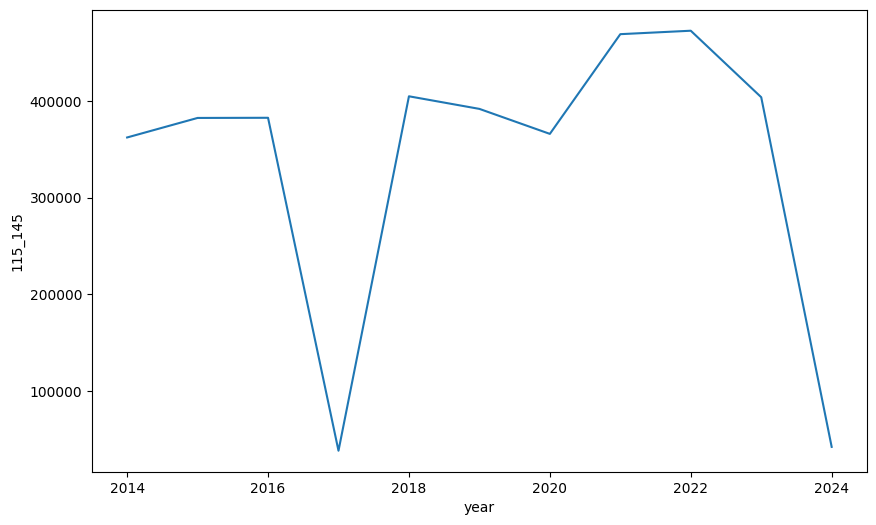

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,6))
sns.lineplot(data = df_ntn_istat[(df_ntn_istat['mun_istat'] == '058091')], x = 'year', y = '115_145')